# Notebook 2 : Filtering + Edge Detection

## Objectif du notebook

Préparer et analyser les images pour :

- réduire le bruit
- améliorer les contours  
- extraire les structures utiles d'objet

---


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [59]:
img_path = os.path.join(dataset_path, "img")

image_paths = sorted([
    os.path.join(img_path, f)
    for f in os.listdir(img_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

print("Number of images:", len(image_paths))
print("Example image:", image_paths[0])

groundtruth_path = os.path.join(dataset_path, "groundtruth.txt")

# ✔ important : delimiter=","
groundtruth = np.loadtxt(groundtruth_path, delimiter=',')

print("Shape groundtruth:", groundtruth.shape)
print("Example bbox:", groundtruth[0])

Number of images: 1661
Example image: ../data/car/car-11/img/00000001.jpg
Shape groundtruth: (1661, 4)
Example bbox: [543. 305. 202.  91.]


OK image chargée : ../data/car/car-11/img/00000001.jpg


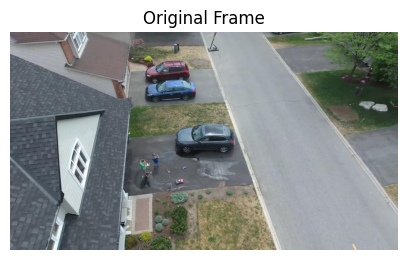

In [16]:
sample_index = 0

sample_path = image_paths[sample_index]
sample_bgr = cv2.imread(sample_path)

if sample_bgr is None:
    raise FileNotFoundError(f"Image non chargée: {sample_path}")

print("OK image chargée :", sample_path)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")
plt.show()

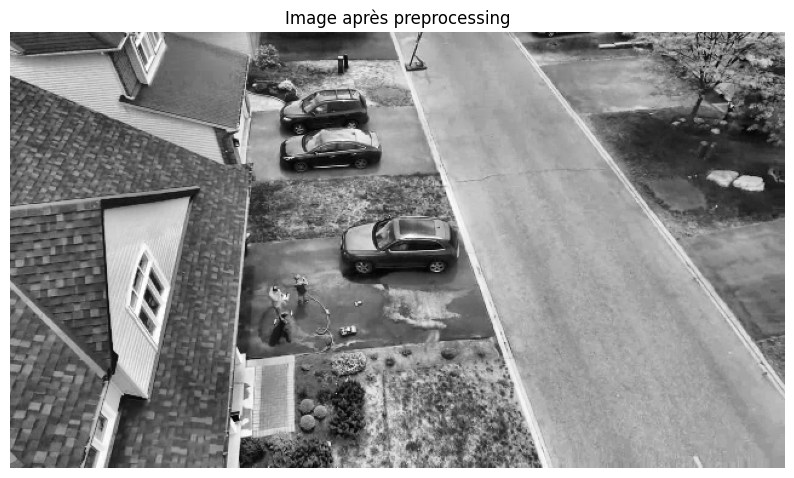

In [20]:
def preprocess_image(image_bgr, target_size=(640, 360), clip_limit=2.0, tile_grid_size=(8, 8)):
    resized = cv2.resize(image_bgr, target_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe_operator = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe_operator.apply(gray)
    normalized = enhanced.astype(np.float32) / 255.0
    return normalized
final_normalized = preprocess_image(sample_bgr)

# Afficher l'image normalisée
plt.figure(figsize=(10, 8))
plt.imshow(final_normalized, cmap='gray')
plt.title('Image après preprocessing')
plt.axis('off')  # Cacher les axes
plt.show()

#Conversion pour filtrage
img = (final_normalized * 255).astype(np.uint8)

## Filtrage (Gaussian / Median / Bilateral)

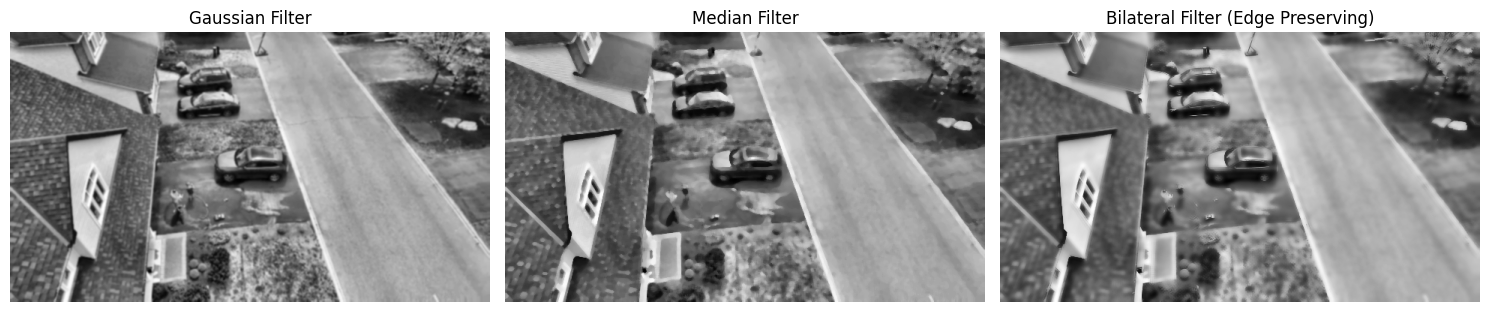

In [21]:
gaussian = cv2.GaussianBlur(img, (5,5), 1.0)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(gaussian, cmap='gray')
axs[0].set_title("Gaussian Filter")
axs[0].axis("off")

axs[1].imshow(median, cmap='gray')
axs[1].set_title("Median Filter")
axs[1].axis("off")

axs[2].imshow(bilateral, cmap='gray')
axs[2].set_title("Bilateral Filter")
axs[2].axis("off")

plt.tight_layout()
plt.show()

###  Comparaison 

- **Gaussien** : lisse uniformément en gardant les contours
- **Médian** : préserve les contours + supprime le bruit 
- **Bilatéral** : théoriquement bon, mais sur-lissage observé ici

###  Pour notre projet (motion estimation)

 **Filtre Gaussien** = meilleur compromis  
→ Réduction du bruit + préservation des contours des véhicules en mouvement

 Sera utilisé avant la détection de contours et l'optical flow.

## Detection du contour

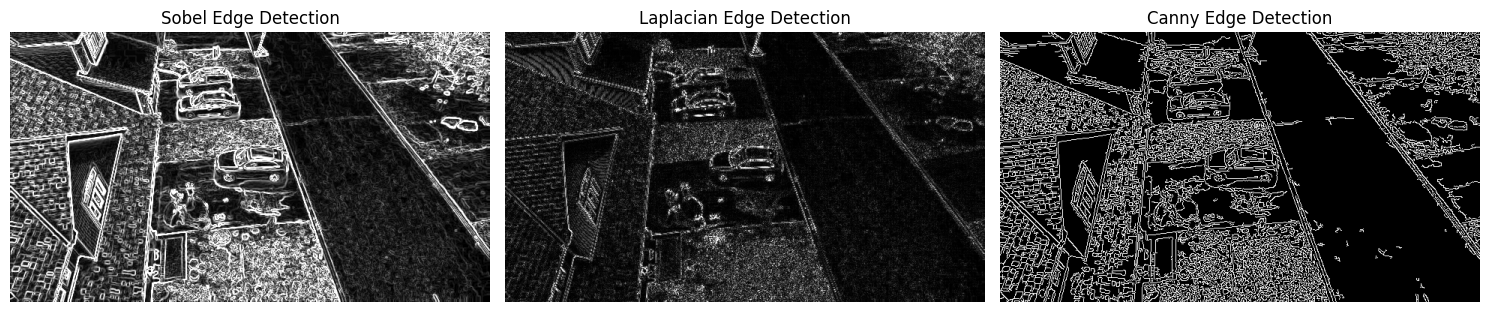

In [23]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobelx**2 + sobely**2)
sobel = np.uint8(np.clip(sobel, 0, 255))

laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

canny = cv2.Canny(img, 50, 150)

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(sobel, cmap='gray')
axs[0].set_title("Sobel Edge Detection")

axs[1].imshow(laplacian, cmap='gray')
axs[1].set_title("Laplacian Edge Detection")

axs[2].imshow(canny, cmap='gray')
axs[2].set_title("Canny Edge Detection")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusion sur les détecteurs de contours

### Comparaison des méthodes testées

| Détecteur | Caractéristiques |
|-----------|------------------|
| **Canny** | Contours les plus stables et bien définis |
| **Sobel** | Fournit des informations directionnelles (gradients X/Y) |
| **Laplacien** | Plus sensible au bruit |

### Recommandation finale

**Canny** est la méthode la plus adaptée pour les tâches d'estimation de mouvement car :

- Contours stables et précis
- Moins sensible au bruit
- Idéal pour l'étape suivante (motion estimation / optical flow)


In [60]:
def read_rgb(image_path):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError("Impossible de lire l'image : " + image_path)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def bbox_to_xywh(row):
    values = np.asarray(row, dtype=float)
    if len(values) == 4:
        x, y, w, h = values
        return int(round(x)), int(round(y)), int(round(w)), int(round(h))
    if len(values) >= 8 and len(values) % 2 == 0:
        xs = values[0::2]
        ys = values[1::2]
        x = np.min(xs)
        y = np.min(ys)
        w = np.max(xs) - x
        h = np.max(ys) - y
        return int(round(x)), int(round(y)), int(round(w)), int(round(h))
    raise ValueError("Format de ground truth non supporté")

def draw_bbox(image_rgb, bbox, color=(255, 0, 0), thickness=3):
    output = image_rgb.copy()
    x, y, w, h = bbox
    cv2.rectangle(output, (x, y), (x + w, y + h), color, thickness)
    return output


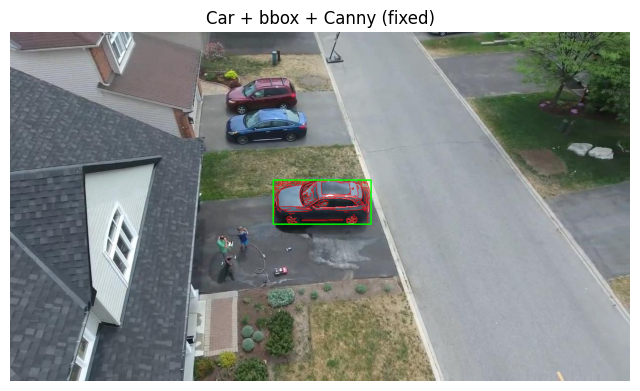

In [61]:

sample_index = 0

# image RGB
image_rgb = read_rgb(image_paths[sample_index])

# bbox safe
bbox = bbox_to_xywh(groundtruth[sample_index])
x, y, w, h = bbox

# ROI voiture
car_roi = image_rgb[y:y+h, x:x+w]

# grayscale
car_gray = cv2.cvtColor(car_roi, cv2.COLOR_RGB2GRAY)

# edges
edges = cv2.Canny(car_gray, 50, 150)

# overlay rouge
car_vis = car_roi.copy()
car_vis[edges > 0] = [255, 0, 0]

# image finale
final_img = image_rgb.copy()
final_img[y:y+h, x:x+w] = car_vis

# bbox
cv2.rectangle(final_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

# display
plt.figure(figsize=(8,5))
plt.imshow(final_img)
plt.title("Car + bbox + Canny (fixed)")
plt.axis("off")
plt.show()